In [110]:
import numpy as np 
from uncertainties import ufloat
from uncertainties import unumpy as unp
from IPython.display import Latex, HTML, Math, display
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress
import pandas as pd
from scipy import constants as c
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator
from sklearn.metrics import r2_score


# zum import von py Dateien
from pathlib import Path
import sys

# Projekt-Root zum importieren von Helper
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from Helper import Helper 

## Flavor

[ 1  8 19 30 38 42 46 53]
tau = -73+/-6
T_(1/2) = -51+/-4


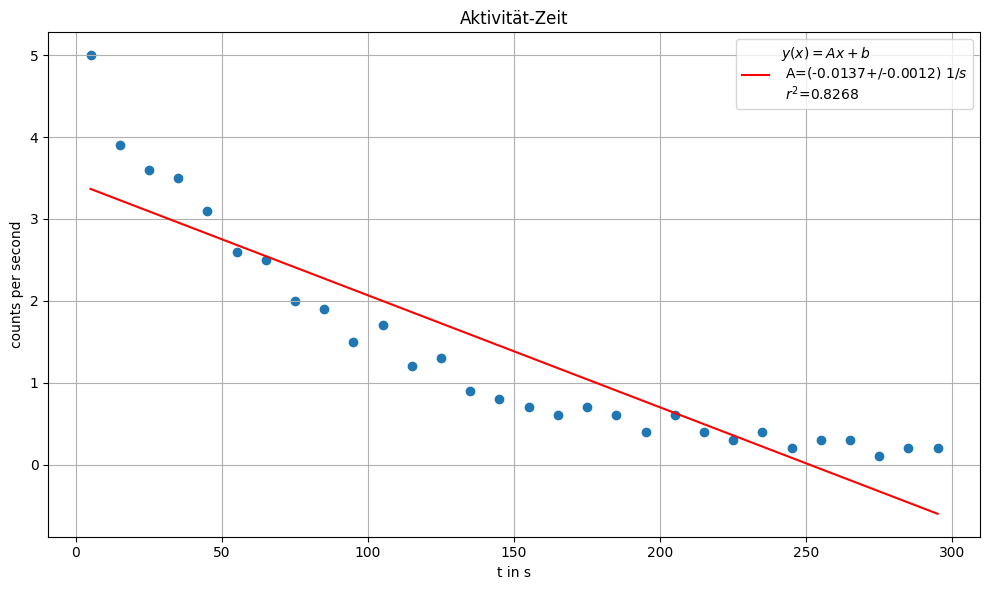

In [111]:
# 1 Hintergrund und Halbwertszeit

# 1.2 Hintergrund
H_Data = pd.read_csv("Hintergrund.csv", sep=',', decimal='.')

H_counts_abs = H_Data["counts"].to_numpy() # alle 60 s
print(H_counts_abs)
# H_counts_per[i] = H_counts_abs[i]
#1.3 Halbwertszeit
# Data
Data = pd.read_csv("GPT-Data.csv", sep=',', decimal='.')

counts = Data["counts"].to_numpy()/10
t = Data["bin_center_s"].to_numpy()

# Fit
def Fit(x, a, b):
    return a*x+b

popt, pcov = curve_fit(Fit, t, counts, p0=[1, 1])

a_opt, b_opt = popt
x_model = np.linspace(min(t), max(t), 100)
y_model = Fit(x_model, a_opt, b_opt)
perr = np.sqrt(np.diag(pcov))

a = ufloat(a_opt, perr[0])

r2 = Helper.r2_curve_fit(popt, t, counts, Fit)

# Rechnung
tau = 1/a
print(f"tau = {tau}")

T_2 = 0.69314718/a
print(f"T_(1/2) = {T_2}")


plt.figure(figsize=(10, 6))
plt.scatter(t, counts)
plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$ \n A=({a}) $1/s$ \n $r^2$={r2:.4f}")
# plt.plot(V, p, "o")
plt.ylabel(r"counts per second")
plt.xlabel(r"t in s")
plt.legend()
plt.title("Aktivität-Zeit")
plt.tight_layout()
plt.grid()
plt.show()

## Flavor


[-3.91631579e+01 -3.51473684e+01 -3.11315789e+01 -2.71157895e+01
 -2.31000000e+01 -1.90842105e+01 -1.50684211e+01 -1.10526316e+01
 -7.03684211e+00 -3.02105263e+00  9.94736842e-01  5.01052632e+00
  9.02631579e+00  1.30421053e+01  1.70578947e+01  2.10736842e+01
  2.50894737e+01  2.91052632e+01  3.31210526e+01  3.71368421e+01
  4.11526316e+01  4.51684211e+01  4.91842105e+01  5.32000000e+01
  5.72157895e+01  6.12315789e+01  6.52473684e+01  6.92631579e+01
  7.32789474e+01  7.72947368e+01  8.13105263e+01  8.53263158e+01
  8.93421053e+01  9.33578947e+01  9.73736842e+01  1.01389474e+02
  1.05405263e+02  1.09421053e+02  1.13436842e+02  1.17452632e+02
  1.21468421e+02  1.25484211e+02  1.29500000e+02  1.33515789e+02
  1.37531579e+02  1.41547368e+02  1.45563158e+02  1.49578947e+02
  1.53594737e+02  1.57610526e+02  1.61626316e+02  1.65642105e+02
  1.69657895e+02  1.73673684e+02  1.77689474e+02  1.81705263e+02
  1.85721053e+02  1.89736842e+02  1.93752632e+02  1.97768421e+02
  2.01784211e+02  2.05800

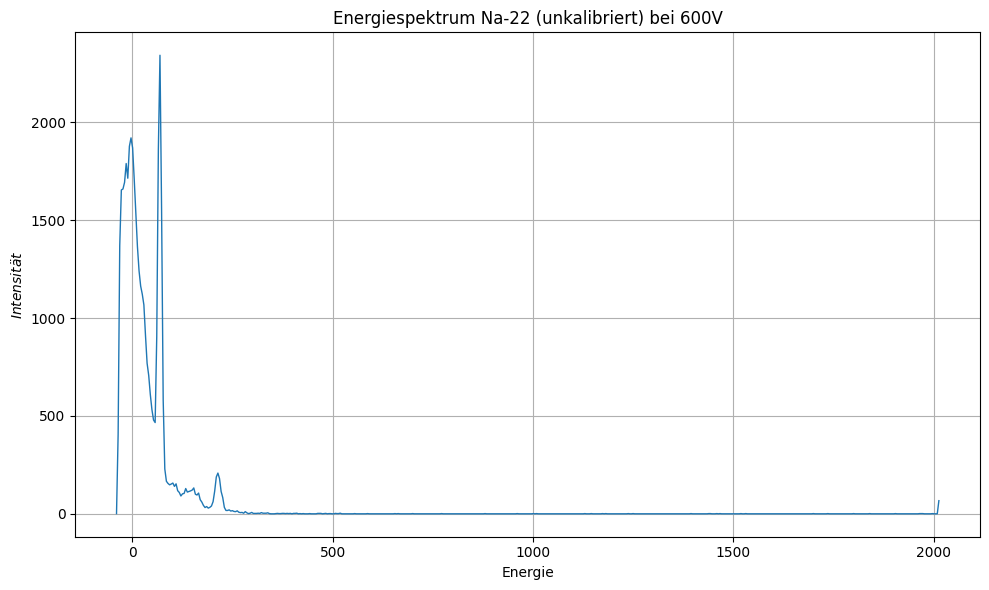

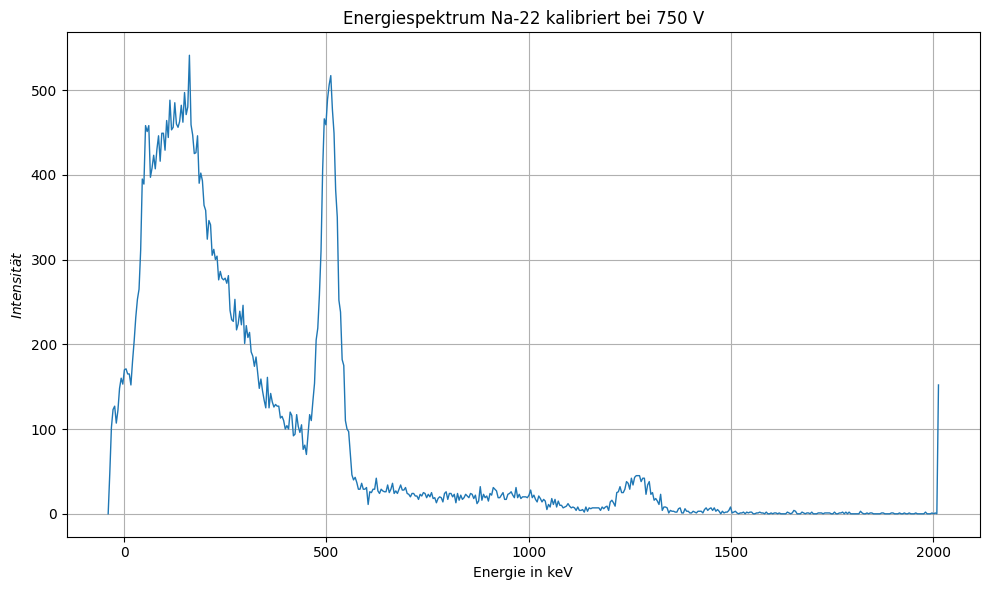

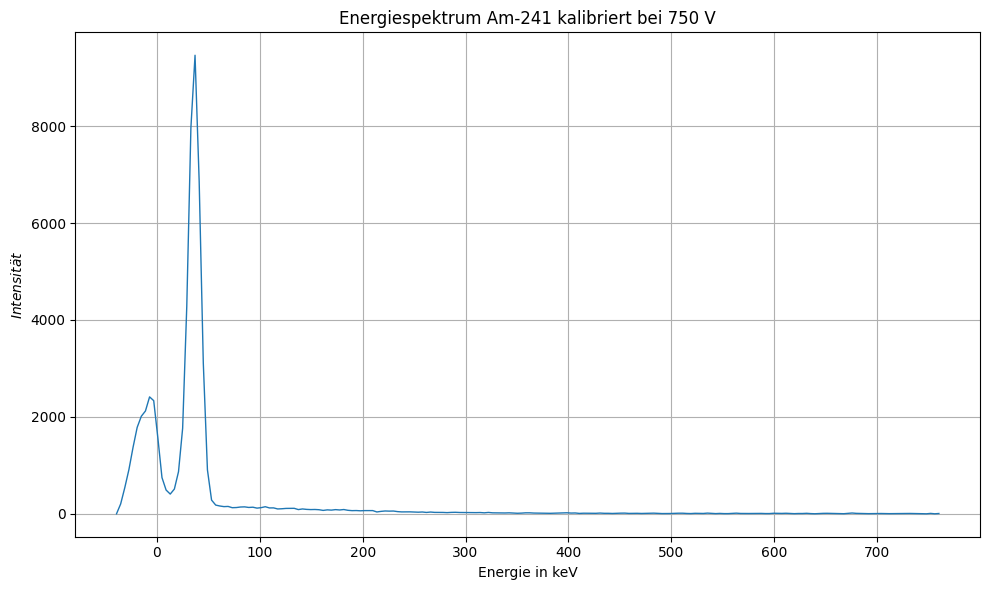

In [131]:
# Spektrum

# Data
x = 11  # Abstand für alle Proben in cm
a = x-1


#Spektrum


Spektrum = pd.read_csv("600-V-Na-2.csv", sep=';', decimal=',')

E = Spektrum["Energie E_A / keV"].to_numpy()
print(E)

N = Spektrum["Ereignisse N_A"].to_numpy()
print(type(N[0]))
print(N[0])


# mask = np.isfinite(E) & np.isfinite(N)
# E, N = E[mask], N[mask]


# Plot with color gradient
plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
plt.plot(E, N, '-', linewidth=1)
plt.xlabel("Energie")
plt.ylabel("$Intensität$")
plt.title("Energiespektrum Na-22 (unkalibriert) bei 600V")
plt.grid()
plt.tight_layout()


# new Data

Spektrum = pd.read_csv("750-V-Na.csv", sep=';', decimal=',')

E = Spektrum["Energie E_A / keV"].to_numpy()
print(E)

N = Spektrum["Ereignisse N_A"].to_numpy()
print(type(N[0]))
print(N[0])


# mask = np.isfinite(E) & np.isfinite(N)
# E, N = E[mask], N[mask]


# Plot with color gradient
plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
plt.plot(E, N, '-', linewidth=1)
plt.xlabel("Energie in keV")
plt.ylabel("$Intensität$")
plt.title("Energiespektrum Na-22 kalibriert bei 750 V")
plt.grid()
plt.tight_layout()

# new Data
Spektrum = pd.read_csv("750-V-Am.csv", sep=';', decimal=',')

E = Spektrum["Energie E_A / keV"].to_numpy()[:200]
print(E)

N = Spektrum["Ereignisse N_A"].to_numpy()[:200]
print(type(N[0]))
print(N[0])


# mask = np.isfinite(E) & np.isfinite(N)
# E, N = E[mask], N[mask]


# Plot with color gradient
plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
plt.plot(E, N, '-', linewidth=1)
plt.xlabel("Energie in keV")
plt.ylabel("$Intensität$")
plt.title("Energiespektrum Am-241 kalibriert bei 750 V")
plt.grid()
plt.tight_layout()



## Flavor


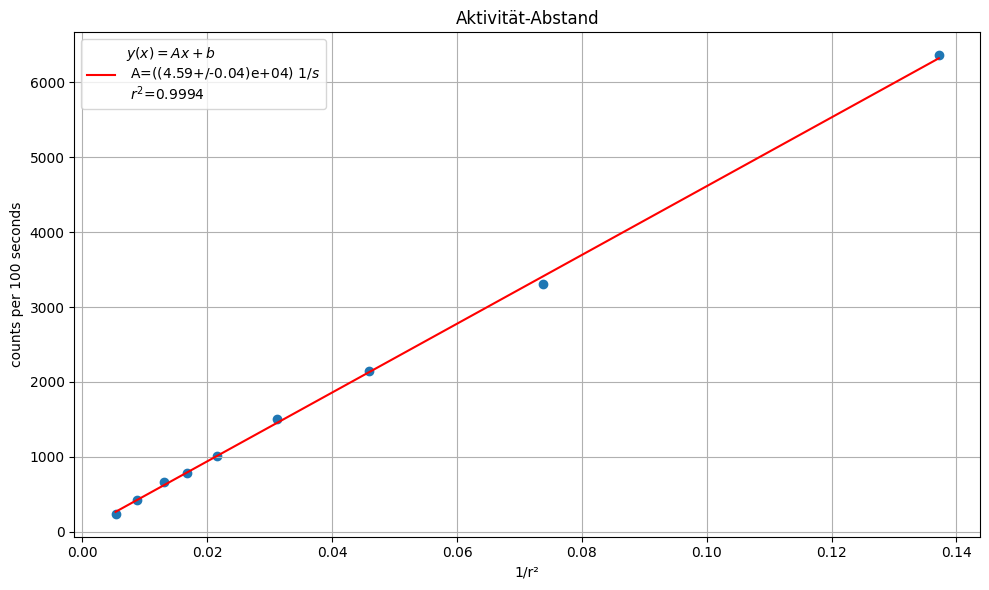

In [113]:
# Abstandsgesetz

#Data

r = np.array([2.70, 3.68, 4.67, 5.66, 6.80, 7.71, 8.73, 10.74, 13.73])    #Abstand +/- 0.02 in cm bzw. +/- 0.005 cm
counts = np.array([6360, 3307, 2145, 1500, 1011, 788, 663, 429, 241])   #counts pro 100s

x = 1/r**2

# Fit
def Fit(x, a, b):
    return a*x+b

popt, pcov = curve_fit(Fit, x, counts, p0=[1, 1])

a_opt, b_opt = popt
x_model = np.linspace(min(x), max(x), 100)
y_model = Fit(x_model, a_opt, b_opt)
perr = np.sqrt(np.diag(pcov))

a = ufloat(a_opt, perr[0])

r2 = Helper.r2_curve_fit(popt, x, counts, Fit)

# Graph (error-bars)
plt.figure(figsize=(10, 6))
plt.scatter(x, counts)
plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$ \n A=({a}) $1/s$ \n $r^2$={r2:.4f}")
# plt.plot(V, p, "o")
plt.ylabel(r"counts per 100 seconds")
plt.xlabel(r"1/r²")
plt.legend()
plt.title("Aktivität-Abstand")
plt.tight_layout()
plt.grid()
plt.show()
